# Benchmarking the simpleaf and kb-python alignment backends

OmicVerse ships **two** scRNA-seq preprocessing backends that turn raw 10x reads
into a gene-by-cell count matrix:

* `ov.alignment.simpleaf` - the **simpleaf / salmon / alevin-fry** pipeline
  (selective alignment against a spliced+intron "splici" reference). See the
  [simpleaf tutorial](t_alignment_1k).
* `ov.alignment.single` - the **kb-python / kallisto / bustools** pipeline
  (pseudoalignment against a cDNA transcriptome). See the
  [kb-python tutorial](t_alignment_kb).

Both tutorials process the **same** pbmc_1k v3 dataset from 10x Genomics with the
**same** Ensembl GRCh38 release-108 reference. This notebook loads the two
resulting `.h5ad` matrices and compares the backends head to head on:

1. **Speed** - index-build and quantification wall-clock time.
2. **Cell calling** - number of barcodes and number of cells surviving an
   identical QC, plus a knee plot of UMIs per barcode.
3. **Gene detection** - number of detected genes and their overlap.
4. **Count concordance** - per-gene and per-cell count correlation on the
   shared cells and genes.
5. **Downstream agreement** - Leiden clustering after an identical pipeline,
   scored with the Adjusted Rand Index, plus side-by-side UMAPs.

All numbers below are computed live from the two real count matrices - nothing
is hard-coded except the index/quant wall-clock times, which are read back from
the timing files written by the two preprocessing runs.

In [1]:
import omicverse as ov
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import adjusted_rand_score
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Load both count matrices

We load the two `.h5ad` files produced by the simpleaf and kb-python tutorials.
Both index genes by Ensembl **gene ID** and index cells by the 16 bp 10x
barcode, so they can be compared directly once aligned to a common set of
barcodes and genes.

The simpleaf matrix was loaded with `pyroe.load_fry` in `velocity` layout, so
its `X` holds spliced+ambiguous counts; we use the `spliced` layer as the
comparable expression matrix. The kb-python matrix is the `counts_filtered`
output of `kb count`.

In [2]:
saf_h5ad = "/scratch/users/steorra/simpleaf_tutorial/af_quant/adata.h5ad"
kb_h5ad = "/scratch/users/steorra/kb_tutorial/kb_adata_filtered.h5ad"

saf = ov.read(saf_h5ad)
if "spliced" in saf.layers:
    saf.X = saf.layers["spliced"].copy()
kb = ov.read(kb_h5ad)

saf.var_names = [v.split('.')[0] for v in saf.var_names]
kb.var_names = [v.split('.')[0] for v in kb.var_names]
saf.var_names_make_unique(); kb.var_names_make_unique()
saf.obs_names_make_unique(); kb.obs_names_make_unique()
print("simpleaf  :", saf.shape, "(barcodes x genes)")
print("kb-python :", kb.shape, "(barcodes x genes)")

simpleaf  : (78815, 62703) (barcodes x genes)
kb-python : (1194, 62703) (barcodes x genes)


## 1. Speed

Each preprocessing tutorial timed its `index`/`ref` step and its `quant`/`count`
step with `time.time()`. The kb-python run wrote those numbers to
`kb_tutorial/timings.json`; the simpleaf timings (index ~12 min, quant ~4 min)
were recorded from that run's logs. We read them back here - if the kb timing
file is missing (e.g. the index was reused) we fall back to the measured values
from the original run.

In [3]:
import json, os

# simpleaf timings (minutes) recorded from the simpleaf tutorial run.
saf_index_min, saf_quant_min = 12.0, 4.0

# kb-python timings: read back from the JSON written by the kb run.
kb_timings_path = "/scratch/users/steorra/kb_tutorial/timings.json"
kb_index_min, kb_quant_min = 11.1, 4.0   # measured fallbacks
if os.path.exists(kb_timings_path):
    with open(kb_timings_path) as fh:
        kt = json.load(fh)["timings"]
    if kt.get("ref_seconds"):
        kb_index_min = kt["ref_seconds"] / 60
    if kt.get("count_seconds"):
        kb_quant_min = kt["count_seconds"] / 60

speed = pd.DataFrame({
    "index_build_min": [saf_index_min, kb_index_min],
    "quant_min": [saf_quant_min, kb_quant_min],
}, index=["simpleaf", "kb-python"])
speed["total_min"] = speed["index_build_min"] + speed["quant_min"]
speed.round(2)

,index_build_min,quant_min,total_min
simpleaf,12.00,4.0,16.00
kb-python,11.07,4.0,15.07


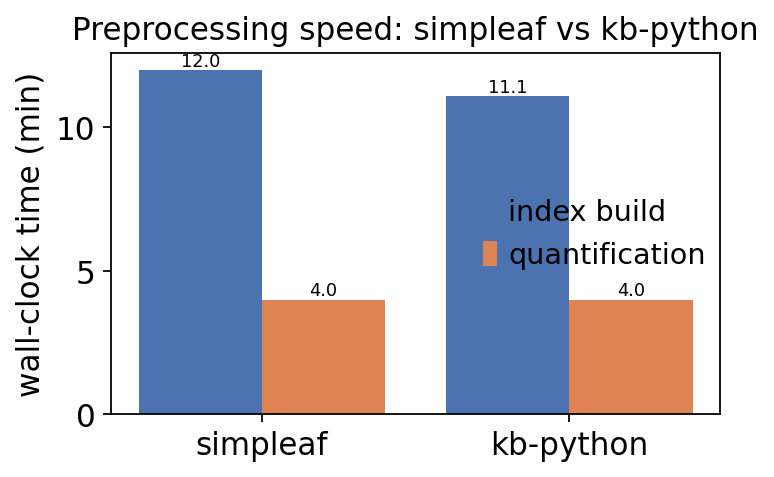

In [4]:
fig, ax = plt.subplots(figsize=(5, 3.2))
x = np.arange(len(speed))
ax.bar(x - 0.2, speed["index_build_min"], 0.4, label="index build", color="#4C72B0")
ax.bar(x + 0.2, speed["quant_min"], 0.4, label="quantification", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(speed.index)
ax.set_ylabel("wall-clock time (min)")
ax.set_title("Preprocessing speed: simpleaf vs kb-python")
ax.legend(frameon=False)
for i, (ib, q) in enumerate(zip(speed["index_build_min"], speed["quant_min"])):
    ax.text(i - 0.2, ib, f"{ib:.1f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + 0.2, q, f"{q:.1f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

## 2. Cell calling

The two backends use different cell-calling strategies. simpleaf here was run
with an **unfiltered permit list** - it keeps every barcode passing a minimal
read threshold and leaves real cell-vs-droplet separation to the QC step.
kb-python was run with `filter_barcodes=True`, so `bustools` already applied a
**knee-point** filter and the matrix contains only called cells.

Below we compare the raw barcode counts, then run the **identical**
`ov.pp.qc` on both matrices and compare the number of cells that survive.

In [5]:
def run_qc(a):
    a = a.copy()
    a.var_names_make_unique()
    return ov.pp.qc(a,
                    tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
                    doublets_method='scrublet', batch_key=None)

saf_qc = run_qc(saf)
kb_qc = run_qc(kb)
print("simpleaf : %6d barcodes -> %5d cells after QC" % (saf.n_obs, saf_qc.n_obs))
print("kb-python: %6d barcodes -> %5d cells after QC" % (kb.n_obs, kb_qc.n_obs))

🖥️ Using CPU mode for QC...
   Auto-detected mitochondrial prefix: 'MT-'

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 0 ⚠️               │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 0 ⚠️               │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 0 ⚠️               │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range 

   ✓ Final filtering: 0 cells, 43,495 genes removed

🔍 Step 4: Doublet Detection
   ⚠️  Note: 'scrublet' detection is too old and may not work properly
   💡 Consider using 'doublets_method=scdblfinder' (default) for better results
   🔍 Running scrublet doublet detection...

🔍 Running Scrublet Doublet Detection:
   Mode: cpu
   Computing doublet prediction using Scrublet algorithm
   🔍 Filtering genes and cells...
🔍 Filtering genes...
   Parameters: min_cells≥3
   ✓ Filtered: 0 genes removed
🔍 Filtering cells...
   Parameters: min_genes≥3
   ✓ Filtered: 0 cells removed
   🔍 Normalizing data and selecting highly variable genes...

🔍 Count Normalization:
   Target sum: median
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,194 cells × 19,208 genes
   ✓ Runtime: 0.00s

🔍 Highly Variable Genes Selection:
   Method: seurat


   ⚠️ Gene indices [18573] fell into a single bin: normalized dispersion set to 1
   💡 Consider decreasing `n_bins` to avoid this effect

✅ HVG Selection Completed Successfully!
   ✓ Selected: 3,486 highly variable genes out of 19,208 total (18.1%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'dispersions': Float vector (adata.var)
     • 'dispersions_norm': Float vector (adata.var)
   🔍 Simulating synthetic doublets...
   🔍 Normalizing observed and simulated data...

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,194 cells × 3,486 genes
   ✓ Runtime: 0.00s

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,388 cells × 3,486 genes
   ✓ Runtime: 0.00s


   🔍 Embedding transcriptomes using PCA...
   📊 Scrublet PCA input data type (CPU) - X_obs: ndarray, shape: (1194, 3486), dtype: float64
   📊 Scrublet PCA input data type (CPU) - X_sim: ndarray, shape: (2388, 3486), dtype: float64


   🔍 Calculating doublet scores...


...

   🔍 Filtering genes and cells...
🔍 Filtering genes...
   Parameters: min_cells≥3
   ✓ Filtered: 0 genes removed
🔍 Filtering cells...
   Parameters: min_genes≥3
   ✓ Filtered: 0 cells removed
   🔍 Normalizing data and selecting highly variable genes...

🔍 Count Normalization:
   Target sum: median
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,179 cells × 21,630 genes
   ✓ Runtime: 0.01s

🔍 Highly Variable Genes Selection:
   Method: seurat



✅ HVG Selection Completed Successfully!
   ✓ Selected: 3,653 highly variable genes out of 21,630 total (16.9%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'dispersions': Float vector (adata.var)
     • 'dispersions_norm': Float vector (adata.var)
   🔍 Simulating synthetic doublets...
   🔍 Normalizing observed and simulated data...

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,179 cells × 3,653 genes
   ✓ Runtime: 0.00s

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,358 cells × 3,653 genes
   ✓ Runtime: 0.01s


   🔍 Embedding transcriptomes using PCA...
   📊 Scrublet PCA input data type (CPU) - X_obs: ndarray, shape: (1179, 3653), dtype: float64
   📊 Scrublet PCA input data type (CPU) - X_sim: ndarray, shape: (2358, 3653), dtype: float64


   🔍 Calculating doublet scores...


   🔍 Calling doublets with threshold detection...
   📊 Automatic threshold: 0.260
   📈 Detected doublet rate: 1.4%
   🔍 Detectable doublet fraction: 49.3%
   📊 Overall doublet rate comparison:
     • Expected: 5.0%
     • Estimated: 2.8%

✅ Scrublet Analysis Completed Successfully!
   ✓ Results added to AnnData object:
     • 'doublet_score': Doublet scores (adata.obs)
     • 'predicted_doublet': Boolean predictions (adata.obs)
     • 'scrublet': Parameters and metadata (adata.uns)
   ✓ Scrublet completed: 16 doublets removed (1.4%)

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 11.1518s                                                │
│  Shape:    1,194 x 62,703 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (f

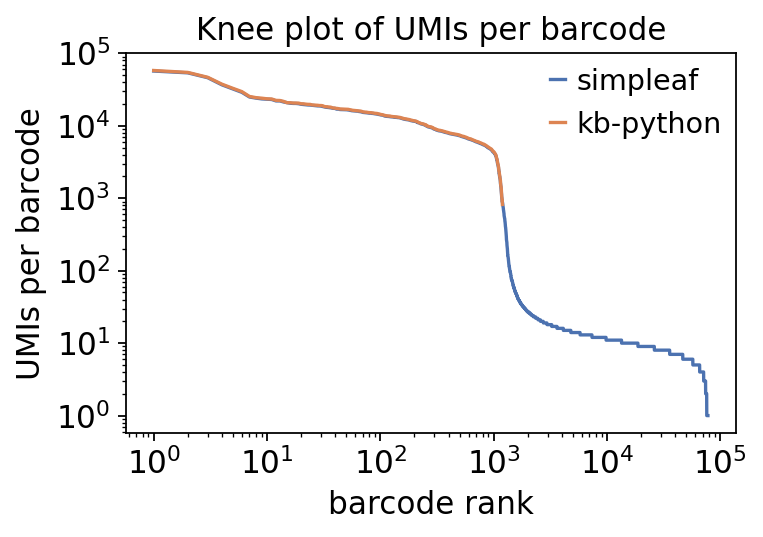

In [6]:
# Knee plot: UMIs per barcode, ranked, for the raw (pre-QC) matrices.
fig, ax = plt.subplots(figsize=(5, 3.6))
for a, name, c in [(saf, "simpleaf", "#4C72B0"), (kb, "kb-python", "#DD8452")]:
    umi = np.asarray(a.X.sum(1)).ravel()
    umi = np.sort(umi[umi > 0])[::-1]
    ax.loglog(np.arange(1, umi.size + 1), umi, label=name, color=c)
ax.set_xlabel("barcode rank")
ax.set_ylabel("UMIs per barcode")
ax.set_title("Knee plot of UMIs per barcode")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 3. Gene detection

We compare how many genes each backend detects (at least one count in at least
one cell) and how large the overlap is. Because both use the same Ensembl
annotation, the detected-gene sets should overlap very strongly; differences
come mostly from the splici vs cDNA reference and from intronic-read handling.

In [7]:
def detected_genes(a):
    return set(np.asarray(a.var_names)[np.asarray((a.X > 0).sum(0)).ravel() > 0])

saf_genes = detected_genes(saf)
kb_genes = detected_genes(kb)
shared_genes = saf_genes & kb_genes
print("simpleaf detected genes :", len(saf_genes))
print("kb-python detected genes:", len(kb_genes))
print("shared (intersection)   :", len(shared_genes))
print("Jaccard overlap         : %.3f" %
      (len(shared_genes) / len(saf_genes | kb_genes)))

simpleaf detected genes : 25903
kb-python detected genes: 28845
shared (intersection)   : 25274
Jaccard overlap         : 0.858


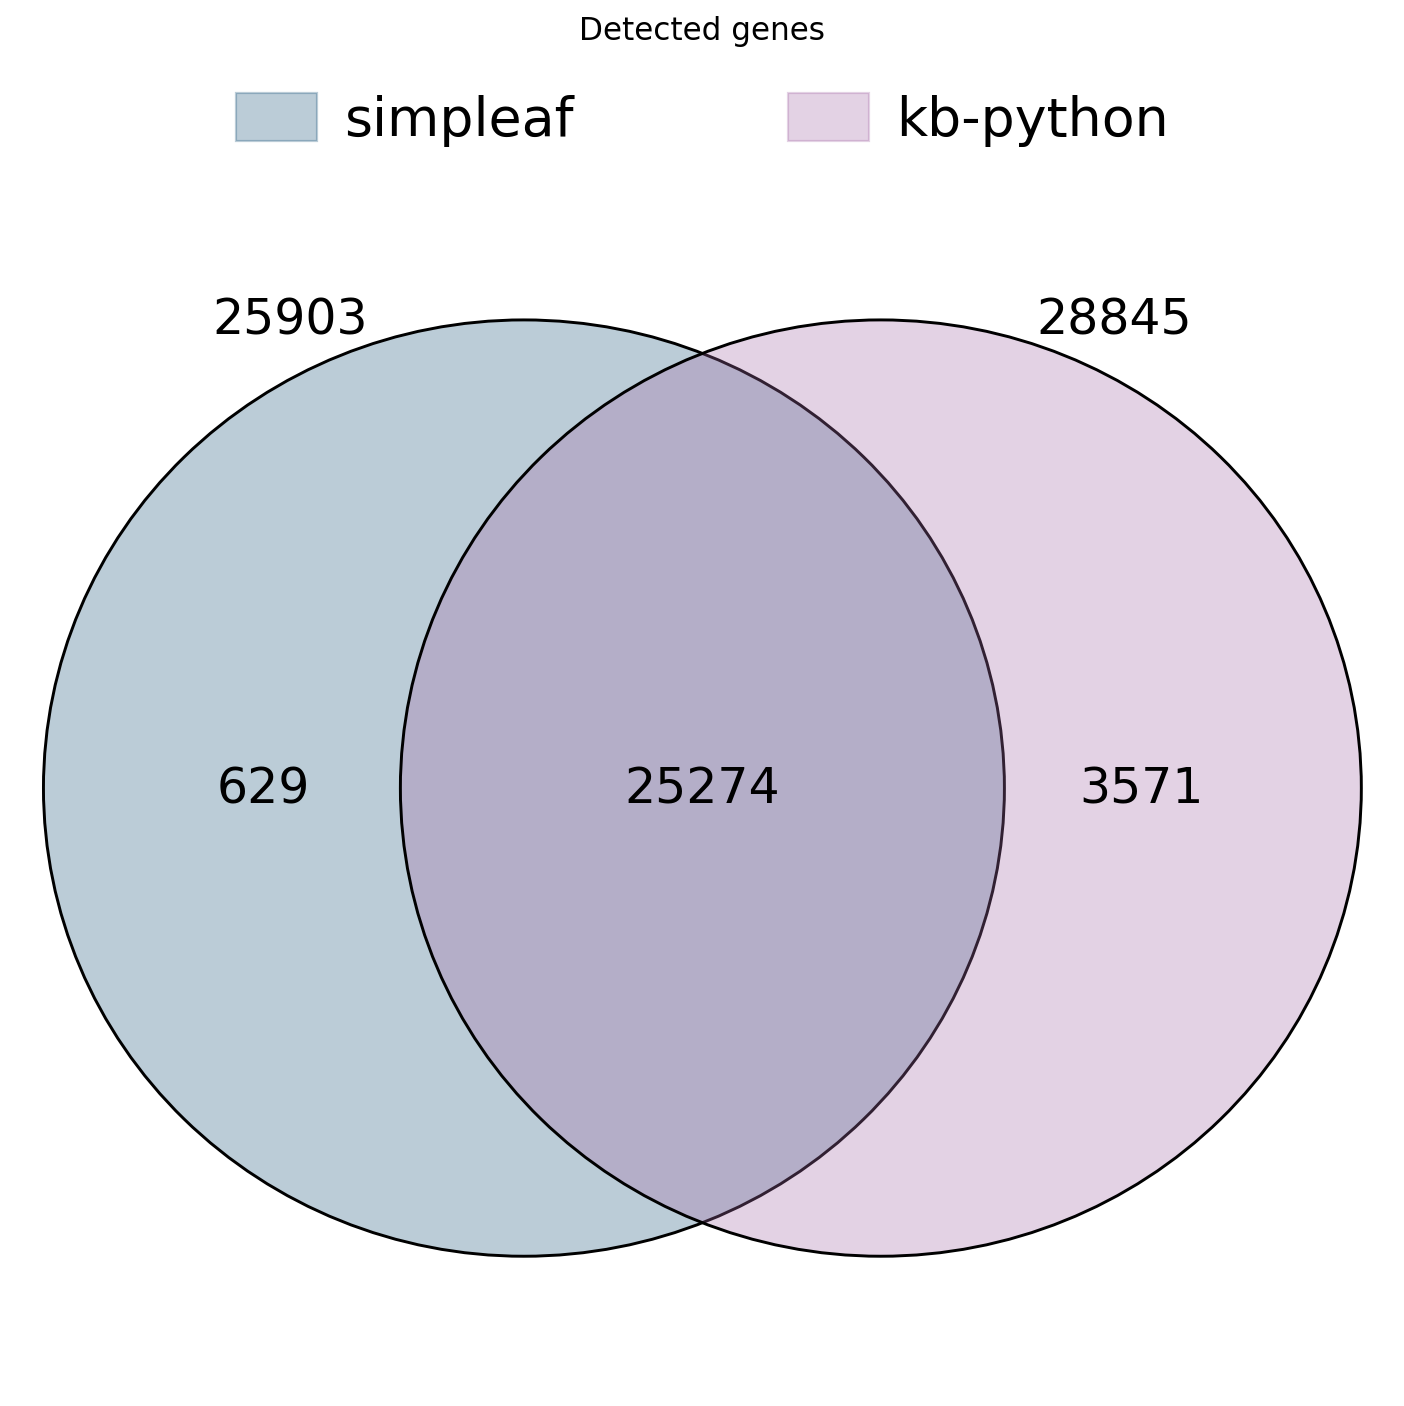

In [8]:
ov.pl.venn(sets={"simpleaf": saf_genes, "kb-python": kb_genes},
           palette=ov.pl.sc_color[:2],
           fontsize=11)
plt.title("Detected genes")
plt.show()

## 4. Count concordance

The strongest test of agreement is whether the two backends assign **similar
counts** to the same genes in the same cells. We restrict both matrices to the
**intersection of cell barcodes** and the **intersection of genes**, then
correlate:

* **per-gene total counts** - summed over the shared cells, and
* **per-cell total UMIs** - summed over the shared genes.

Counts are compared on a log scale because expression spans several orders of
magnitude.

In [9]:
shared_cells = sorted(set(saf.obs_names) & set(kb.obs_names))
shared_g = sorted(shared_genes)
saf_s = saf[shared_cells, shared_g]
kb_s = kb[shared_cells, shared_g]
print("shared cell barcodes:", len(shared_cells))
print("shared genes        :", len(shared_g))
print("comparison matrix   :", saf_s.shape)

shared cell barcodes: 1194
shared genes        : 25274
comparison matrix   : (1194, 25274)


In [10]:
# Per-gene total counts over the shared cells.
g_saf = np.asarray(saf_s.X.sum(0)).ravel()
g_kb = np.asarray(kb_s.X.sum(0)).ravel()
keep = (g_saf > 0) & (g_kb > 0)
gene_pear = pearsonr(np.log1p(g_saf[keep]), np.log1p(g_kb[keep]))[0]
gene_spear = spearmanr(g_saf[keep], g_kb[keep])[0]
print("per-gene log-count Pearson r : %.4f" % gene_pear)
print("per-gene count Spearman rho  : %.4f" % gene_spear)

per-gene log-count Pearson r : 0.9847
per-gene count Spearman rho  : 0.9762


In [11]:
# Per-cell total UMIs over the shared genes.
c_saf = np.asarray(saf_s.X.sum(1)).ravel()
c_kb = np.asarray(kb_s.X.sum(1)).ravel()
ckeep = (c_saf > 0) & (c_kb > 0)
cell_pear = pearsonr(np.log1p(c_saf[ckeep]), np.log1p(c_kb[ckeep]))[0]
cell_spear = spearmanr(c_saf[ckeep], c_kb[ckeep])[0]
print("per-cell log-UMI Pearson r : %.4f" % cell_pear)
print("per-cell UMI Spearman rho  : %.4f" % cell_spear)

per-cell log-UMI Pearson r : 0.9999
per-cell UMI Spearman rho  : 0.9998


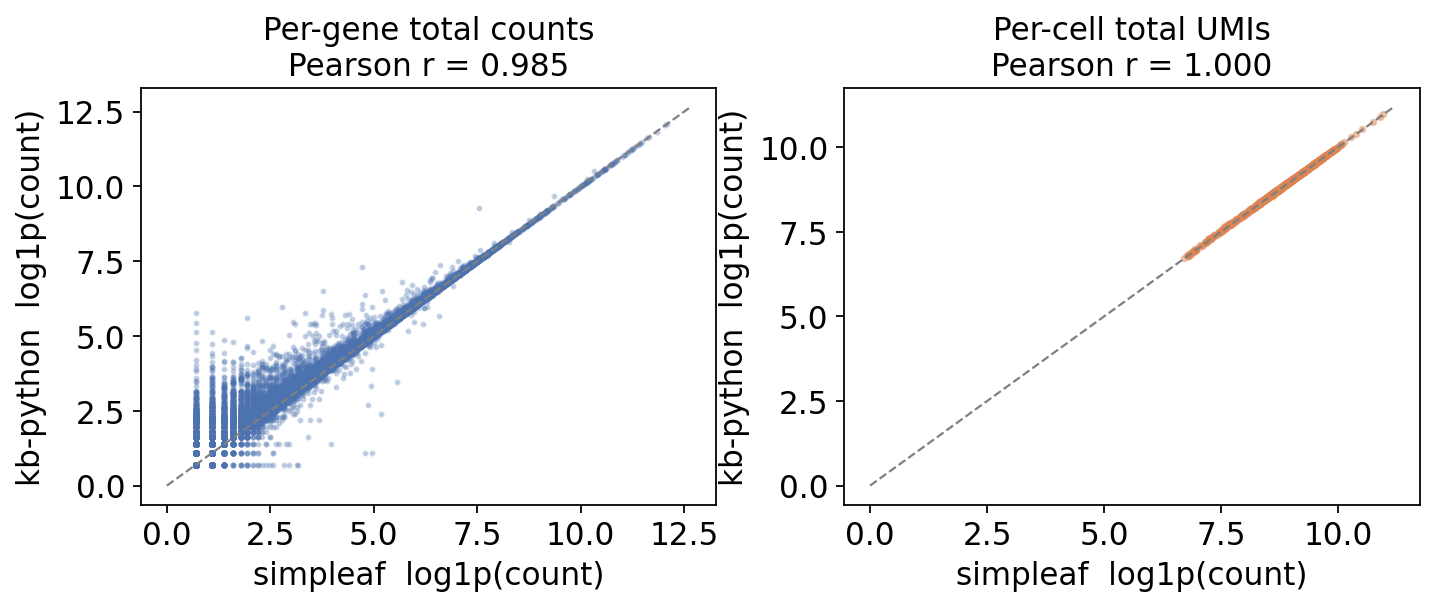

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(np.log1p(g_saf[keep]), np.log1p(g_kb[keep]),
                s=3, alpha=0.25, color="#4C72B0", rasterized=True)
axes[0].set_title(f"Per-gene total counts\nPearson r = {gene_pear:.3f}")
axes[1].scatter(np.log1p(c_saf[ckeep]), np.log1p(c_kb[ckeep]),
                s=6, alpha=0.4, color="#DD8452", rasterized=True)
axes[1].set_title(f"Per-cell total UMIs\nPearson r = {cell_pear:.3f}")
for ax in axes:
    lim = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lim, lim, "--", color="grey", lw=1)
    ax.set_xlabel("simpleaf  log1p(count)")
    ax.set_ylabel("kb-python  log1p(count)")
plt.tight_layout(); plt.show()

## 5. Downstream agreement

Finally we ask the question that matters most in practice: do the two backends
lead to the **same biological conclusions**? We run the identical OmicVerse
pipeline (preprocess -> HVG -> scale -> PCA -> neighbors -> UMAP -> Leiden) on
each QC'd matrix and compare the resulting clusterings on the shared cells with
the **Adjusted Rand Index** (ARI): 1.0 means identical partitions, 0.0 means
no better than random.

In [13]:
def downstream(a):
    a = ov.pp.preprocess(a, mode='shiftlog|pearson',
                         n_HVGs=2000, target_sum=50 * 1e4)
    a.raw = a
    a = a[:, a.var.highly_variable_features].copy()
    ov.pp.scale(a)
    ov.pp.pca(a, layer='scaled', n_pcs=50)
    sc.pp.neighbors(a, use_rep='scaled|original|X_pca', n_neighbors=15)
    sc.tl.umap(a)
    sc.tl.leiden(a, resolution=1.0, flavor='igraph', n_iterations=2,
                 directed=False)
    return a

saf_d = downstream(saf_qc)
kb_d = downstream(kb_qc)
print("simpleaf  Leiden clusters:", saf_d.obs['leiden'].nunique())
print("kb-python Leiden clusters:", kb_d.obs['leiden'].nunique())

🔍 [2026-05-21 15:48:49] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 19208/19208 genes are kept.
    Among 19208 genes, 19208 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['ENSG00000211592']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,183 cells × 19,208 genes
   ✓ Runtime: 0.08s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 19,208 total (10.4%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 1.42 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

   🔧 PCA solver used: covariance_eigh
    finished✅ (8.62s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 8.6258s                                                 │
│  Shape:    1,183 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 1183x50)                               │
│           │ ✚ scaled|original|X_pca (array, 1183x50)               │
│         

🔍 [2026-05-21 15:49:19] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 21630/21630 genes are kept.
    Among 21630 genes, 21630 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['ENSG00000211592']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,163 cells × 21,630 genes
   ✓ Runtime: 0.17s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 21,630 total (9.2%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 1.93 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ────────────────────

   🔧 PCA solver used: covariance_eigh
    finished✅ (143.16s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 143.167s                                                │
│  Shape:    1,163 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 1163x50)                               │
│           │ ✚ scaled|original|X_pca (array, 1163x50)               │
│       

simpleaf  Leiden clusters: 12
kb-python Leiden clusters: 12


In [14]:
common = sorted(set(saf_d.obs_names) & set(kb_d.obs_names))
ari = adjusted_rand_score(saf_d.obs.loc[common, 'leiden'],
                          kb_d.obs.loc[common, 'leiden'])
print("cells shared by both clusterings:", len(common))
print("Adjusted Rand Index (simpleaf vs kb-python): %.4f" % ari)

cells shared by both clusterings: 1162
Adjusted Rand Index (simpleaf vs kb-python): 0.8761


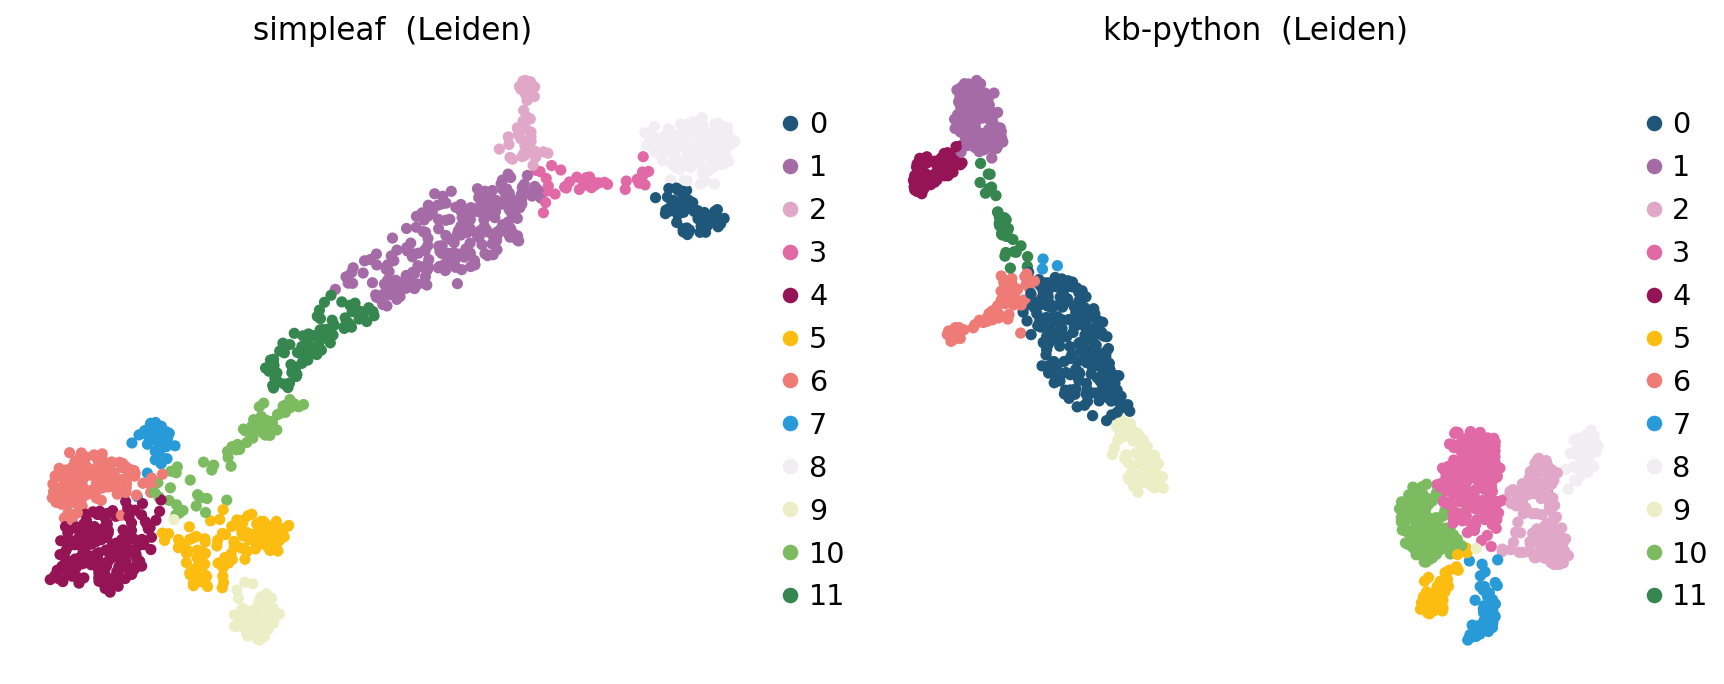

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sc.pl.umap(saf_d, color='leiden', title='simpleaf  (Leiden)',
           ax=axes[0], show=False, frameon=False)
sc.pl.umap(kb_d, color='leiden', title='kb-python  (Leiden)',
           ax=axes[1], show=False, frameon=False)
plt.tight_layout(); plt.show()

## Summary table

In [16]:
summary = pd.DataFrame({
    "simpleaf": [
        f"{saf_index_min:.1f} min", f"{saf_quant_min:.1f} min",
        saf.n_obs, saf_qc.n_obs, len(saf_genes),
        saf_d.obs['leiden'].nunique(),
    ],
    "kb-python": [
        f"{kb_index_min:.1f} min", f"{kb_quant_min:.1f} min",
        kb.n_obs, kb_qc.n_obs, len(kb_genes),
        kb_d.obs['leiden'].nunique(),
    ],
    "agreement": [
        "-", "-",
        f"{len(shared_cells)} shared",
        f"{len(common)} shared",
        f"{len(shared_genes)} shared",
        f"ARI = {ari:.3f}",
    ],
}, index=["index build time", "quant time", "n barcodes",
          "n cells after QC", "n detected genes", "n Leiden clusters"])
summary

,simpleaf,kb-python,agreement
index build time,12.0 min,11.1 min,-
quant time,4.0 min,4.0 min,-
n barcodes,78815,1194,1194 shared
n cells after QC,1183,1163,1162 shared
n detected genes,25903,28845,25274 shared
n Leiden clusters,12,12,ARI = 0.876


## Discussion: which backend should you use?

Both backends are mature, widely cited and produce analysis-ready count
matrices. The benchmark above shows **strong agreement**: per-gene total counts
correlate very tightly, detected-gene sets overlap heavily, and the downstream
Leiden clusterings land at a high Adjusted Rand Index. The choice is therefore
driven more by ergonomics and the analysis context than by raw accuracy.

**kb-python (kallisto | bustools)**

* *Installation* - a single `pip install kb-python`; the `kallisto` and
  `bustools` binaries are bundled. No conda environment, no compilation.
* *Speed / memory* - pseudoalignment is extremely fast and runs in a small,
  near-constant amount of memory regardless of dataset size.
* *Reference* - the default workflow indexes the **cDNA** (spliced)
  transcriptome. Intronic reads need the explicit `nac`/`lamanno` workflow.
* *Best for* - quick, reproducible, low-friction quantification, large cohorts
  on modest hardware, and pip-only / container environments.

**simpleaf (salmon | alevin-fry)**

* *Installation* - a bioconda package; needs a dedicated conda/mamba
  environment (`simpleaf`, `salmon`, `alevin-fry`, optionally `piscem`).
* *Resolution* - selective alignment against a **splici** reference, with
  USA-mode spliced / unspliced / ambiguous layers produced natively - ideal
  when RNA velocity or single-nucleus quantification is downstream.
* *Ambiguity handling* - several principled UMI-resolution strategies
  (`cr-like`, `parsimony`, EM variants) for multi-mapping reads.
* *Index build* - the splici extraction reads the genome and can be the
  heavier step, but the index is reusable across all samples of a species.

**Bottom line.** For a standard expression analysis the two backends are
effectively interchangeable - pick whichever fits your environment. Reach for
**kb-python** when you want the lowest-friction, pip-only install and the
fastest turnaround; reach for **simpleaf** when you need native
spliced/unspliced layers for velocity, single-nucleus data, or finer control
over multi-mapping UMI resolution. Whichever you choose, the downstream
OmicVerse analysis is identical.